In [120]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
stocks = [
    "HDFCBANK.NS",
    "INFY.NS",
    "HINDUNILVR.NS",
    "RELIANCE.NS",
    "MARUTI.NS"
]

data = yf.download(
    stocks, start = "2021-01-01", end = "2026-06-01"
)

[*********************100%***********************]  5 of 5 completed


Data Exploration

In [38]:
data.head()

Price            Close                                                      \
Ticker     HDFCBANK.NS HINDUNILVR.NS      INFY.NS    MARUTI.NS RELIANCE.NS   
Date                                                                         
2021-01-01  663.905762   2195.604004  1086.097168  7371.631836  897.047119   
2021-01-04  659.689453   2231.422852  1110.051758  7382.174805  898.559021   
2021-01-05  664.674316   2253.538818  1114.834106  7337.271973  887.388367   
2021-01-06  661.809265   2222.962402  1104.752563  7311.537598  863.986084   
2021-01-07  659.805969   2178.407471  1087.562256  7251.587402  862.586975   

Price             High                                                      \
Ticker     HDFCBANK.NS HINDUNILVR.NS      INFY.NS    MARUTI.NS RELIANCE.NS   
Date                                                                         
2021-01-01  672.268328   2210.731468  1090.448665  7426.454661  901.334860   
2021-01-04  669.938866   2234.641471  1111.559688  7432.876535  902.192298   
2021-01-05  666.561163   2259.424202  1119.314770  7354.092367  895.286881   
2021-01-06  670.870655   2253.033457  1121.899903  7426.933398  887.343111   
2021-01-07  667.423135   2237.124144  1118.151694  7384.187352  877.864981   

Price       ...        Open                                          \
Ticker      ... HDFCBANK.NS HINDUNILVR.NS      INFY.NS    MARUTI.NS   
Date        ...                                                       
2021-01-01  ...  670.870681   2202.822772  1083.899962  7335.882296   
2021-01-04  ...  669.938866   2211.651332  1093.464530  7417.349657   
2021-01-05  ...  661.180199   2211.650752  1104.666309  7341.632677   
2021-01-06  ...  668.541243   2249.171159  1120.176554  7335.881821   
2021-01-07  ...  667.376558   2236.480465  1116.729910  7356.967815   

Price                       Volume                                    \
Ticker     RELIANCE.NS HDFCBANK.NS HINDUNILVR.NS   INFY.NS MARUTI.NS   
Date                                                                   
2021-01-01  897.272755     8810938        830096   4253550    767574   
2021-01-04  900.477225    15740192       1614486   7208454    598645   
2021-01-05  888.697235    14386824       2356303   8145280    562668   
2021-01-06  887.297984    22134050       1641627   7161715    840678   
2021-01-07  866.807025    19894842       2403881  10954918    642968   

Price                   
Ticker     RELIANCE.NS  
Date                    
2021-01-01    10015175  
2021-01-04    24513534  
2021-01-05    24123091  
2021-01-06    46401468  
2021-01-07    32325918  

[5 rows x 25 columns]

In [39]:
prices = data['Close']
prices.head()

Ticker,HDFCBANK.NS,HINDUNILVR.NS,INFY.NS,MARUTI.NS,RELIANCE.NS
Date,,,,,
2021-01-01,663.905762,2195.604004,1086.097168,7371.631836,897.047119
2021-01-04,659.689453,2231.422852,1110.051758,7382.174805,898.559021
2021-01-05,664.674316,2253.538818,1114.834106,7337.271973,887.388367
2021-01-06,661.809265,2222.962402,1104.752563,7311.537598,863.986084
2021-01-07,659.805969,2178.407471,1087.562256,7251.587402,862.586975


In [40]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1337 entries, 2021-01-01 to 2026-05-29
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   HDFCBANK.NS    1337 non-null   float64
 1   HINDUNILVR.NS  1337 non-null   float64
 2   INFY.NS        1337 non-null   float64
 3   MARUTI.NS      1337 non-null   float64
 4   RELIANCE.NS    1337 non-null   float64
dtypes: float64(5)
memory usage: 62.7 KB


In [41]:
prices.describe()

Ticker,HDFCBANK.NS,HINDUNILVR.NS,INFY.NS,MARUTI.NS,RELIANCE.NS
count,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000
mean,778.003928,2342.118934,1424.388193,10221.722878,1228.561424
std,96.880783,179.414593,187.584627,2776.423509,178.912256
min,606.489197,1811.667358,1067.657349,6187.338379,831.353943
25%,703.672913,2211.880859,1291.257935,7847.735840,1104.204224
50%,762.099487,2352.600098,1407.202515,9804.081055,1206.437378
75%,823.383911,2454.479980,1533.008789,12294.333984,1391.864624
max,996.419800,2939.454346,1901.082886,17292.000000,1584.971802


In [42]:
prices.isnull().sum()

Ticker
HDFCBANK.NS      0
HINDUNILVR.NS    0
INFY.NS          0
MARUTI.NS        0
RELIANCE.NS      0
dtype: int64

In [43]:
prices.to_csv("stock_prices.csv")

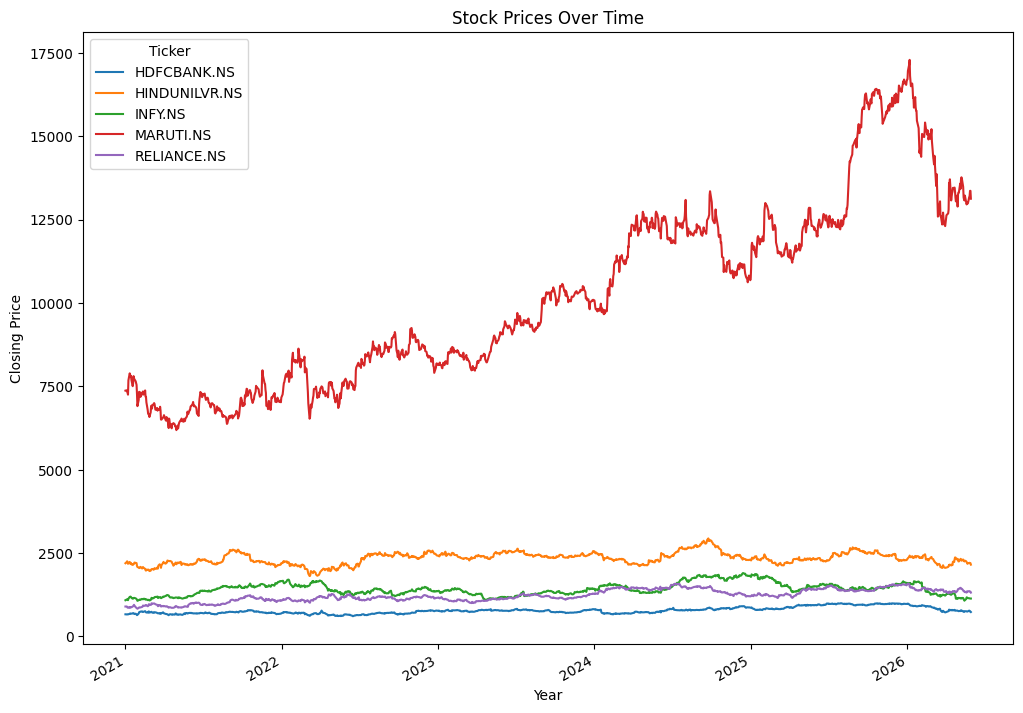

In [136]:
prices.plot(figsize = (12,9))
plt.title("Stock Prices Over Time")
plt.xlabel("Year")
plt.ylabel("Closing Price")
plt.show()

Maruti showed the strongest upward trend among the selected stocks, with substantial price growth over the analysis period, also experiencing noticeable price swings.

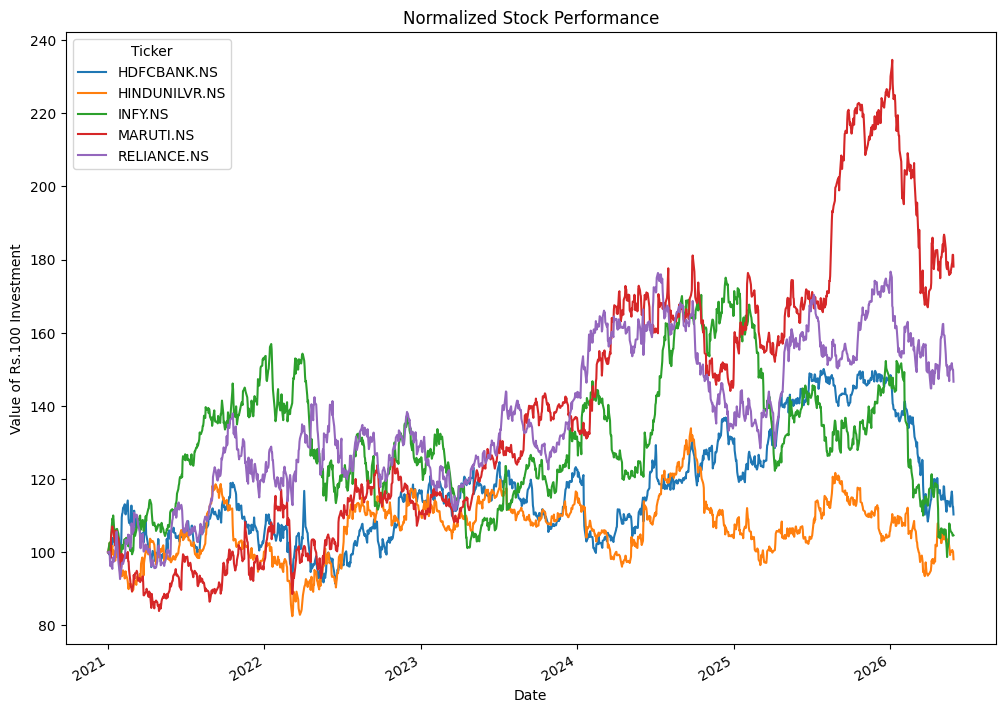

In [45]:
normalized = prices / prices.iloc[0] * 100
normalized.plot(figsize = (12,9))
plt.title("Normalized Stock Performance")
plt.ylabel("Value of Rs.100 Investment")
plt.show()

A Rs. 100 investment yielded different outcomes across stocks. Maruti and Reliance delivered the strongest growth, while HINDUNILVR showed the weakest performance.

In [46]:
daily_returns = prices.pct_change()
volatility = daily_returns.std()
print(volatility.sort_values(ascending = False))

Ticker
INFY.NS          0.015532
MARUTI.NS        0.014891
RELIANCE.NS      0.014435
HDFCBANK.NS      0.013672
HINDUNILVR.NS    0.012828
dtype: float64


In [48]:
total_return = ((prices.iloc[-1] / prices.iloc[0]) - 1) * 100
total_return = total_return.round(2)
total_return.sort_values(ascending = False)

Ticker
MARUTI.NS        78.07
RELIANCE.NS      46.61
HDFCBANK.NS      10.32
INFY.NS           4.62
HINDUNILVR.NS    -1.92
dtype: float64

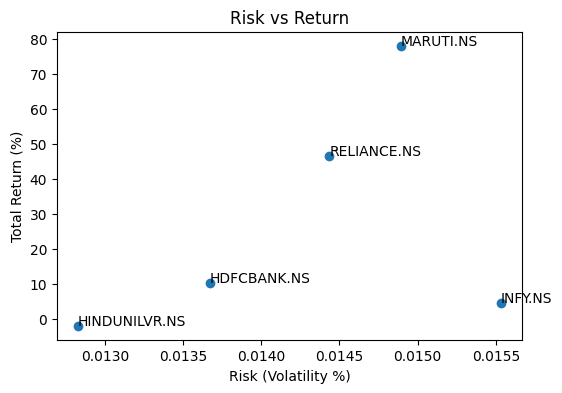

In [70]:
plt.figure(figsize=(6,4))
plt.scatter(volatility, total_return)

for stock in total_return.index:
    plt.annotate(stock,(volatility[stock], total_return[stock]))

plt.xlabel("Risk (Volatility %)")
plt.ylabel("Total Return (%)")
plt.title("Risk vs Return")
plt.show()

Maruti delivered the highest total return (78.07%) with high volatility, while HINDUNILVR recorded a negative return (-1.92%) with the least volatility.
Despite having highest volatility, Infosys delivered very less returns (4.62%), while Reliance achieved strong returns (46.61%) with moderate volatility. HDFC Bank maintained moderate returns (10.32%) with comparatively lower volatility.
It suggests that higher risk did not always result in higher returns.

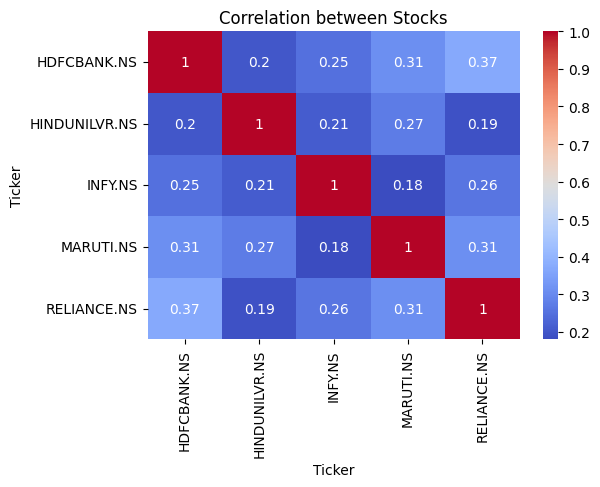

In [60]:
plt.figure(figsize=(6,4))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation between Stocks")
plt.show()

No stock pair exhibited a very strong correlation. The relatively low correltaions among the stocks ehnanced portfolio diversification and helped reduce overall portfolio risk.

In [75]:
annual_return = daily_returns.mean()*252*100
annual_return.round(2).sort_values(ascending=False)

Ticker
MARUTI.NS        13.67
RELIANCE.NS       9.84
HDFCBANK.NS       4.21
INFY.NS           3.90
HINDUNILVR.NS     1.71
dtype: float64

In [76]:
annual_volatility = daily_returns.std() * (252**0.5) * 100
annual_volatility.round(2).sort_values(ascending=False)

Ticker
INFY.NS          24.66
MARUTI.NS        23.64
RELIANCE.NS      22.91
HDFCBANK.NS      21.70
HINDUNILVR.NS    20.36
dtype: float64

In [103]:
weights_equal = [0.2,0.2,0.2,0.2,0.2]
portfolio_return1 = (daily_returns * weights_equal).sum(axis=1)

In [105]:
portfolio_annual_return1 = (portfolio_return1.mean()*252*100).round(2)
portfolio_annual_return1

np.float64(6.66)

In [106]:
portfolio_annual_volatility1 = (portfolio_return1.std()*(252**0.5) * 100).round(2)
portfolio_annual_volatility1

np.float64(14.41)

In [118]:
weights_growth = [0.10,0.05,0.10,0.45,0.30]
portfolio_return2 = (daily_returns * weights_growth).sum(axis=1)

In [109]:
portfolio_annual_return2 = (portfolio_return2.mean()*252*100).round(2)
portfolio_annual_return2


np.float64(9.99)

In [110]:
portfolio_annual_volatility2 = (portfolio_return2.std()*(252**0.5) * 100).round(2)
portfolio_annual_volatility2

np.float64(16.54)

In [112]:
weights_conservative = [0.30,0.25,0.10,0.15,0.20]
portfolio_return3 = (daily_returns * weights_conservative).sum(axis=1)

In [113]:
portfolio_annual_return3 = (portfolio_return3.mean()*252*100).round(2)
portfolio_annual_return3

np.float64(6.09)

In [114]:
portfolio_annual_volatility3 = (portfolio_return3.std()*(252**0.5) * 100).round(2)
portfolio_annual_volatility3

np.float64(14.44)

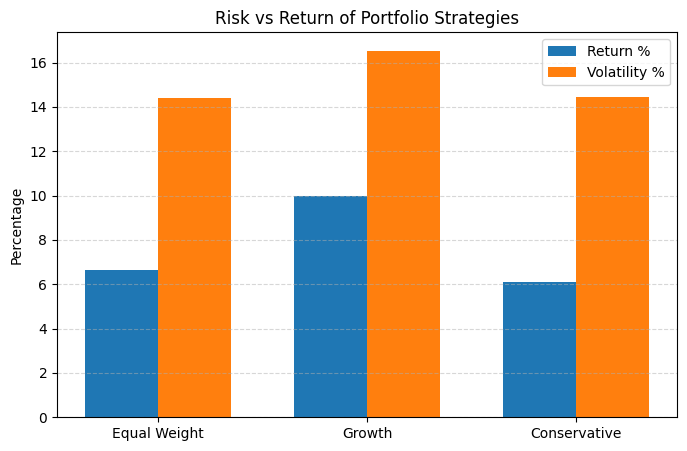

In [127]:
portfolios = ["Equal Weight", "Growth", "Conservative"]
returns = [portfolio_annual_return1, portfolio_annual_return2, portfolio_annual_return3]
volatility = [portfolio_annual_volatility1, portfolio_annual_volatility2, portfolio_annual_volatility3]

x = np.arange(len(portfolios))
width = 0.35

plt.figure(figsize = (8,5))

plt.bar(x - width/2, returns, width, label = "Return %")
plt.bar(x + width/2, volatility, width, label = "Volatility %")
plt.xticks(x, portfolios)
plt.ylabel("Percentage")
plt.title("Risk vs Return of Portfolio Strategies")
plt.legend()

plt.grid(axis = 'y', linestyle = '--', alpha = 0.5)
plt.show()

The Growth Portfolio, with higher allocations to Maruti (45%) and Reliance (30%), generated the highest annual return of 9.99% but also caried the highest volatility of 16.54%. The Equal Weight Portfolio, distributing 20% across each stock, achieved a return of 6.66% with the lowest volatility of 14.41%, providing the most balanced risk_return profile. Despite allocating a larger share to relatively stable stocks such as HDFC Bank and HINDUNILVR, the Conservative Portfolio delivered a lower return of 6.09% while exhibiting a similar volatility of 14.44%.